## Carga de librerias y de la base de datos

In [ ]:
import pandas as pd #permite trabajar con excel
import numpy as np #para trabajar con matematicas
import random #generar numeros aleatorios
import copy

In [ ]:
#cargamos los datos de consumos REALES
datosConsumoReal = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ConsumoReal(MEDICAMENTOS)2022-2024.xlsx')

datosConsumoReal.head()
datosConsumoReal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Código         390 non-null    object
 1   Desripción     390 non-null    object
 2   Concentración  390 non-null    object
 3   2022           390 non-null    int64 
 4   2023           390 non-null    int64 
 5   2024           390 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 18.4+ KB


In [ ]:
#cargamos los datos de PRECIOS de diferentes fuentes
datosPrecios = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Precios(MEDICAMENTOS)2022-2024Completo.xlsx')
datosPrecios.head()
datosPrecios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Código                    390 non-null    object 
 1   Desripción                390 non-null    object 
 2   Concentración             390 non-null    object 
 3   Costo2022 (SU)            390 non-null    int64  
 4   Costo2023 (SU)            390 non-null    float64
 5   Costo2024 (SU)            390 non-null    float64
 6   Precio LINAME Junio 2022  381 non-null    float64
 7   Precio LINAME Sep 2023    382 non-null    float64
 8   Precio LINAME Junio 2024  390 non-null    float64
 9   Precio LINAME Nov. 2024   382 non-null    float64
 10  Precio LINAME Abril 2025  382 non-null    float64
 11  Precio LINAME Junio 2025  382 non-null    float64
dtypes: float64(8), int64(1), object(3)
memory usage: 36.7+ KB


In [ ]:
#confirmamos que la lista de cantidades con la lista de precios esten ordenadas
#cada medicamento corresponde a su precio
print(datosConsumoReal.loc[335])
print(datosPrecios.loc[335])


Código                                          V-08-03
Desripción                             CONTRASTE IODADO
Concentración    Según disponibilidad (100 ml o 200 ml)
2022                                                 19
2023                                                  0
2024                                                  0
Name: 335, dtype: object
Código                                                     V-08-03
Desripción                                        CONTRASTE IODADO
Concentración               Según disponibilidad (100 ml o 200 ml)
Costo2022 (SU)                                                   0
Costo2023 (SU)                                                 0.0
Costo2024 (SU)                                                 0.0
Precio LINAME Junio 2022                                    312.26
Precio LINAME Sep 2023                                      312.26
Precio LINAME Junio 2024                                    312.26
Precio LINAME Nov. 2024             

In [ ]:
#cargo los datos del POA 2024
datosPoa = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/POA(IMEDICAMENTOS) 20242.xlsx')
datosPoa.head()
datosPoa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Código           390 non-null    object 
 1   CATIDAD A PEDIR  390 non-null    float64
 2   COSTO UNITARIO   390 non-null    float64
 3   TOTAL COSTO      390 non-null    float64
dtypes: float64(3), object(1)
memory usage: 12.3+ KB


In [ ]:
#cargo los datos inventario
datosInventario = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Inventarios.xlsx')
datosInventario.head()
datosInventario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Código  390 non-null    object
 1   2021    390 non-null    int64 
 2   2022    390 non-null    int64 
 3   2023    390 non-null    int64 
 4   2024    390 non-null    int64 
 5   2025    390 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 18.4+ KB


## PARAMETROS




1. TP: techo presupuestario disponible en el periodo t
2. n: número total de medicamentos i
3. PRA_i^t: precio referencial AGEMED del medicamento i en el periodo t
4. PRE_i^t: precio referencial externo del medicamento i en el periodo t
5. z_i^t: consumo real del medicamento i en el periodo t
6. y_i^t: tasa de crecimiento/decrecimiento del medicamento i en el periodo t
7. S_i^t: saldo (stock) del medicamento i en el periodo t
8. CPM_i: consumo promedio mensual del medicamento i
9. LSMED_i: límite superior de meses de existencia permitidos para el medicamento i



In [ ]:
# 1Para el TP sumamos todo los registros de "TOTAL COSTO" de datosPOA
#TP = datosPoa["TOTAL COSTO"].sum()
TP = (datosPoa["CATIDAD A PEDIR"]*datosPrecios['Precio LINAME Junio 2024']).sum() #
print("Techo presupuestario TP = ",np.round(TP,2))
# 2 para N obtenemos la cantidad de variables en datosConsumoReal
N = datosConsumoReal.shape[0]
print(N)


Techo presupuestario TP =  3628267.26
390


In [ ]:
#3. para el PRA obtenemos el precio LINAME 2024 de datosPrecio
#redondeamos a 2 decimales
PRA = datosPrecios["Precio LINAME Junio 2024"]
#PRA = datosPoa["COSTO UNITARIO"] ### preguntar QUE PRECIOS corresponden ###
#PRA = np.round(PRA,2)
#print(PRA)
#observacion: hay medicamentos que no tienen precio en LINAME (solucion reemplace del costo del SU)
#verificacion
print(np.isnan(PRA).any())

False


In [ ]:
#4. Para el PRE tomamos los valores PRA y le sumamos un 25% a su precio
PRE = PRA * 1.15
PRE = np.round(PRE,2)
#print(PRE)
#Aqui se puede cargar la base de datos con PRE reales!
print(np.isnan(PRE).any())

False


In [ ]:
#5. para z sacamos el consumo REAL de las gestiones que necesitamos
#z convertido en array
z = np.array([datosConsumoReal[2022].values, datosConsumoReal[2023].values, datosConsumoReal[2024].values])
print(z)

[[  976 60271  2992 ...     0     0     0]
 [  980 52020  1577 ...     0     0     0]
 [  928 52824  2246 ...     0     0     0]]


In [ ]:
#6. realizamos el calculo de la tasa tomando en cuenta
#cantidades gestion 2022 y gestion 2023 (usamos indices para indicar la gestion)
AU = (z[1]-z[0])/z[0]
#Existe problema con la division entre cero:
#infinito = 5/0 (division de cualquier numero entre cero)
#nan = 0/0     (division de cero entre cero)
print(AU[350:375])

#para el caso de valores nan (Not a number) asumimos que no existe crecimiento ni decrecimiento (0.0)
### PREGUNTAR ESTE CASO EN PARTICULAR ###
AU = np.where(np.isnan(AU), 0, AU)
#para el caso especial INFINITO asumimos crecimiento del 100%
#limpiamos valores inf (infinitos) y remplazamos por 1.0
AU = np.where(~np.isfinite(AU), 0, AU)
#verificamos
print(AU[350:375])

#finalmente obtenemos y_i
y = (1+AU)
print(y[350:375])



[-1.         -1.         27.         -0.83333333  1.         -1.
  1.         -1.         -1.          2.12380952         inf         inf
         inf         inf         inf         inf         inf         inf
         inf         nan         nan         nan         nan         nan
         nan]
[-1.         -1.         27.         -0.83333333  1.         -1.
  1.         -1.         -1.          2.12380952  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]
[ 0.          0.         28.          0.16666667  2.          0.
  2.          0.          0.          3.12380952  1.          1.
  1.          1.          1.          1.          1.          1.
  1.          1.          1.          1.          1.          1.
  1.        ]


/tmp/ipykernel_21315/643951399.py:3: RuntimeWarning: divide by zero encountered in divide
  AU = (z[1]-z[0])/z[0]
/tmp/ipykernel_21315/643951399.py:3: RuntimeWarning: invalid value encountered in divide
  AU = (z[1]-z[0])/z[0]


In [ ]:
#ARREGLAMOS LA SUPERPROYECCION QUE SE GENERA
top10 = np.sort(y)[-10:][::-1]
print(top10)
y = np.clip(y, None, 7)
top10 = np.sort(y)[-10:][::-1]
print(top10)

[28.         16.5        14.51666667 10.          6.5         6.
  5.3         5.          4.7665996   4.72222222]
[7.         7.         7.         7.         6.5        6.
 5.3        5.         4.7665996  4.72222222]


In [ ]:
#7. Si : Saldo total del sku i en el periodo t
S = np.array([datosInventario[2022].values, datosInventario[2023].values, datosInventario[2024].values])
print(S)

[[  259 17098  1037 ...   130     0    11]
 [   79  6378   960 ...     0     0    11]
 [  114 17574   214 ...     0     0     0]]


In [ ]:
#	8. CPMi	: Consumo promedio mensual del sku i
# calculando sobre el último año de consumo (2024) dividido entre 12
CPM = z[2] / 12
#print(CPM)
#9. LSMEDi	: Límite superior de meses de existencia disponibles del SKU i
# Este es un valor de gestión, 8 meses para esta prueba
LSMED = 8

In [ ]:
#MED
MED = np.divide(S[2], CPM, out=np.zeros_like(S[2], dtype=float), where=CPM!=0)

In [ ]:
# Definimos la variable P_i^t (Binaria)
#P es variable de desicion o es parámetro?
P = (MED < LSMED).astype(int)
print(P)

[1 1 1 0 1 0 0 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0
 0 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1
 1 1 1 0 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1
 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


## Cálculos necesarios:


In [ ]:
# demanda proyectada
d = np.ceil(z[1]*y).astype(int) #redondeado al entero superior

# requerimiento neto de compra ecuacion 15
S_prev = S[1]
r = np.maximum(0, d - S_prev)
r = r.astype(int)

# requerimiento ajustado por P y tomando en cuenta inventario
r = (P * np.maximum(0, d - S_prev)).astype(int)

In [ ]:
total_requerido = r.sum()
costo_requerido = (r*PRA).sum()
print(total_requerido, costo_requerido, "requerido")

total_real = z[2].sum() - S[1].sum()
costo_real = (np.maximum(0, z[2]-S[1])*PRA).sum()
print(total_real, costo_real, "real menos saldo")

total_pedido = round(datosPoa['CATIDAD A PEDIR'].sum())
costo_pedido = (datosPoa['CATIDAD A PEDIR']*PRA).sum()
print(total_pedido, round(costo_pedido,2), "pedido en poa2024")

total_pedido_saldo = round(datosPoa['CATIDAD A PEDIR'].sum()) + S[1].sum()
costo_pedido_saldo = (datosPoa['CATIDAD A PEDIR']*PRA).sum() + (S[1]*PRA).sum()
print(total_pedido_saldo, round(costo_pedido_saldo,2), "pedido en poa2024 mas lo que habia de saldo")

924588 4273639.761737987 requerido
884480 3245508.44133032 real menos saldo
816632 3628267.26 pedido en poa2024
1062984 4314961.63 pedido en poa2024 mas lo que habia de saldo


## Funciones
ya tenemos la capacidad de referencia ahora pasamo a generar la población inicial utilizando las funciones ya definidas

In [ ]:
import numpy as np

# Función objetivo
def calcular_fitness(wi, xi, PRA, PRE):

    # Convertir entradas a arreglos numpy con tipos numéricos seguros
    wi  = np.asarray(wi, dtype=float)
    xi  = np.asarray(xi, dtype=float)
    PRA = np.asarray(PRA, dtype=float)
    PRE = np.asarray(PRE, dtype=float)

    # Costos por tipo de compra
    costo_planificado = float(np.sum(wi * PRA))  # sum_i wi_i * PRA_i
    costo_extra       = float(np.sum(xi * PRE))  # sum_i xi_i * PRE_i

    # Costo total (CT)
    CT = costo_planificado + costo_extra

    return CT, costo_planificado, costo_extra


def generar_poblacion_inicial(pop_size, r, TP, PRA, seed=None, max_intentos=200):
    """
    Población: pop -> shape (pop_size, 2, n)
    Individuo: ind -> shape (2, n) donde ind[0]=w, ind[1]=x

    Restricciones:
      (17) w + x = r
      (14) sum_i w_i * PRA_i <= TP
    """
    rng = np.random.default_rng(seed)

    r = np.asarray(r, dtype=int)
    PRA = np.asarray(PRA, dtype=float)
    TP = float(TP)

    n = r.size
    pop = np.zeros((pop_size, 2, n), dtype=int)

    # Para recortar costo rápido: primero los más caros
    idx_caros = np.argsort(-PRA)

    for k in range(pop_size):
        mejor_w = None
        mejor_costo = -1.0  # para aprovechar presupuesto sin pasarse

        for _ in range(max_intentos):
            # 1) w aleatorio en [0, r]
            w = rng.integers(r/2, r + 1, size=n, dtype=int)

            # 2) Ajuste para cumplir presupuesto (greedy recortando ítems caros)
            costo = float(np.sum(w * PRA))
            if costo > TP:
                exceso = costo - TP
                for i in idx_caros:
                    if exceso <= 0:
                        break
                    if w[i] == 0 or PRA[i] == 0:
                        continue
                    bajar = int(np.ceil(exceso / PRA[i]))
                    bajar = min(bajar, w[i])
                    w[i] -= bajar
                    exceso -= bajar * PRA[i]

            # 3) Verificación
            costo = float(np.sum(w * PRA))
            if costo <= TP and np.all((0 <= w) & (w <= r)):
                if costo > mejor_costo:
                    mejor_costo = costo
                    mejor_w = w.copy()

        if mejor_w is None:
            # Fallback seguro: todo extra (w=0)
            mejor_w = np.zeros(n, dtype=int)

        x = r - mejor_w  # (17) exacta

        pop[k, 0, :] = mejor_w
        pop[k, 1, :] = x

    return pop

def es_factible(ind, r, TP, PRA):
    w = ind[0]
    x = ind[1]

    # (17)
    ok17 = np.all(w + x == r)

    # no negatividad
    okNN = np.all(w >= 0) and np.all(x >= 0)

    # (14)
    costo_w = float(np.sum(w * PRA))
    ok14 = costo_w <= float(TP) + 1e-9

    return ok17 and okNN and ok14, costo_w

def reparar(ind, r, TP, PRA):
    w = ind[0].copy()
    r = np.asarray(r, dtype=int)
    PRA = np.asarray(PRA, dtype=float)
    TP = float(TP)

    # 1) asegurar enteros y límites
    w = np.asarray(w, dtype=int)
    w = np.clip(w, 0, r)

    # 2) recorte por presupuesto si es necesario
    costo = float(np.sum(w * PRA))
    if costo > TP:
        exceso = costo - TP
        idx_caros = np.argsort(-PRA)  # caros primero
        for i in idx_caros:
            if exceso <= 0:
                break
            if w[i] == 0 or PRA[i] == 0:
                continue
            bajar = int(np.ceil(exceso / PRA[i]))
            bajar = min(bajar, w[i])
            w[i] -= bajar
            exceso -= bajar * PRA[i]

    # 3) reconstruir x para cumplir (17)
    x = r - w

    # 4) devolver individuo reparado
    ind_rep = np.vstack([w, x]).astype(int)
    return ind_rep




In [ ]:
pop = generar_poblacion_inicial(pop_size=10, r=r, TP=TP, PRA=PRA, seed=123)

# Individuo k:
ind = pop[0]        # shape (2, n)
w = ind[0]
x = ind[1]

fitness, costo_planificado, costo_extra = calcular_fitness(w, x, PRA, PRE)
print(costo_planificado, costo_extra)
print(np.shape(pop))
print(np.shape(pop[1]))

print(es_factible(ind, r, TP, PRA))

3550477.272182796 831677.3400000001
(10, 2, 390)
(2, 390)
(True, 3550477.272182796)


In [ ]:
#FUNCIONES BWO

import numpy as np

def procreacion(parent1, parent2, r, TP, PRA, PRE, CR,
               n_hijos_objetivo=None, rng=None, max_intentos=20000):


    if rng is None:
        rng = np.random.default_rng()

    # Asegurar tipos
    r   = np.asarray(r, dtype=int)
    PRA = np.asarray(PRA, dtype=float)
    PRE = np.asarray(PRE, dtype=float)
    TP  = float(TP)

    n = r.size

    # Cantidad de hijos a intentar generar (antes de canibalismo)
    if n_hijos_objetivo is None:
        n_hijos_objetivo = n  # por defecto, 1 hijo por gen (puedes cambiarlo)
    n_hijos_objetivo = int(n_hijos_objetivo)
    n_hijos_objetivo = max(2, n_hijos_objetivo)

    # Extraer w de los padres (solo cruzamos w)
    w1 = np.asarray(parent1[0], dtype=int)
    w2 = np.asarray(parent2[0], dtype=int)

    children = []
    fit_children = []
    intentos = 0

    while len(children) < n_hijos_objetivo and intentos < max_intentos:
        intentos += 1

        # 1) Elegir n/2 índices únicos
        k = n // 2
        if k == 0:
            idxs = np.array([], dtype=int)
        else:
            idxs = rng.choice(n, size=k, replace=False)

        # 2) Crear hijos copiando a los padres (solo w)
        w_child1 = w1.copy()
        w_child2 = w2.copy()

        # 3) Cruce solo afecta a n/2 genes
        #    Child1[i] = round(alpha*P1[i] + (1-alpha)*P2[i]) en idxs
        alfas = rng.random(size=idxs.size)  # un alfa por gen cruzado
        for j, i in enumerate(idxs):
            alfa = alfas[j]
            w_child1[i] = int(np.rint(alfa * w1[i] + (1.0 - alfa) * w2[i]))
            w_child2[i] = int(np.rint(alfa * w2[i] + (1.0 - alfa) * w1[i]))

        # 4) Limitar w para asegurar x>=0 con w+x=r
        w_child1 = np.clip(w_child1, 0, r)
        w_child2 = np.clip(w_child2, 0, r)

        # 5) Reconstruir x para cumplir (17)
        x_child1 = (r - w_child1).astype(int)
        x_child2 = (r - w_child2).astype(int)

        ind1 = np.vstack([w_child1, x_child1]).astype(int)
        ind2 = np.vstack([w_child2, x_child2]).astype(int)

        # 6) Verificar factibilidad y reparar si no cumple (14) o algo
        fact1, _ = es_factible(ind1, r, TP, PRA)
        if not fact1:
            ind1 = reparar(ind1, r, TP, PRA)
            fact1, _ = es_factible(ind1, r, TP, PRA)

        if fact1:
            CT1, _, _ = calcular_fitness(ind1[0], ind1[1], PRA, PRE)
            children.append(ind1)
            fit_children.append(CT1)

        if len(children) < n_hijos_objetivo:
            fact2, _ = es_factible(ind2, r, TP, PRA)
            if not fact2:
                ind2 = reparar(ind2, r, TP, PRA)
                fact2, _ = es_factible(ind2, r, TP, PRA)

            if fact2:
                CT2, _, _ = calcular_fitness(ind2[0], ind2[1], PRA, PRE)
                children.append(ind2)
                fit_children.append(CT2)

    if len(children) == 0:
        return np.empty((0, 2, n), dtype=int), np.array([], dtype=float)

    children = np.asarray(children, dtype=int)            # (k,2,n)
    fit_children = np.asarray(fit_children, dtype=float)  # (k,)

    # 7) Ordenar por fitness (min)
    idx = np.argsort(fit_children)
    children = children[idx]
    fit_children = fit_children[idx]

    # 8) Canibalismo: mantener una fracción CR de los mejores
    ns = int(len(children) * CR)
    ns = max(1, ns)

    return children[:ns], fit_children[:ns]


import numpy as np

def mutacion_gaussiana(pop1, PM, r, TP, PRA, PRE,
                       sigma=7, frac_genes=0.10, rng=None, max_intentos=20000):

    if rng is None:
        rng = np.random.default_rng()

    r   = np.asarray(r, dtype=int)
    PRA = np.asarray(PRA, dtype=float)
    PRE = np.asarray(PRE, dtype=float)
    TP  = float(TP)

    pop_size = len(pop1)
    n = r.size

    # número de mutantes a generar
    nm = int(pop_size * PM)
    nm = max(1, nm)

    # número de genes a mutar por individuo
    k = int(np.round(frac_genes * n))
    k = max(1, k)

    pop3 = []
    fit_mutation = []

    intentos = 0
    while len(pop3) < nm and intentos < max_intentos:
        intentos += 1

        # Elegir individuo aleatorio
        ind = pop1[rng.integers(0, pop_size)]
        w_mut = np.asarray(ind[0], dtype=int).copy()

        # Mutar k genes
        idxs = rng.choice(n, size=k, replace=False)
        deltas = np.rint(rng.normal(loc=0.0, scale=sigma, size=k)).astype(int)
        for j, i in enumerate(idxs):
            w_mut[i] = w_mut[i] + int(deltas[j])

        # Limitar para que x no sea negativo con (17)
        w_mut = np.clip(w_mut, 0, r)

        # Reconstruir x para cumplir (17)
        x_mut = (r - w_mut).astype(int)

        ind_mut = np.vstack([w_mut, x_mut]).astype(int)

        # Verificar factibilidad y reparar si hace falta
        fact, _ = es_factible(ind_mut, r, TP, PRA)
        if not fact:
            ind_mut = reparar(ind_mut, r, TP, PRA)
            fact, _ = es_factible(ind_mut, r, TP, PRA)

        if not fact:
            continue

        # Fitness (FO)
        CT, _, _ = calcular_fitness(ind_mut[0], ind_mut[1], PRA, PRE)

        pop3.append(ind_mut)
        fit_mutation.append(CT)

    if len(pop3) == 0:
        return np.empty((0, 2, n), dtype=int), np.array([], dtype=float)

    return np.asarray(pop3, dtype=int), np.asarray(fit_mutation, dtype=float)


## MAIN

In [ ]:
# PARAMETROS BWO
PR = 0.8    # Procreation rate (fracción de población usada como padres)
CR = 0.4    # Fracción de hijos que sobreviven tras canibalismo (según tu interpretación)
PM = 0.8    # Tasa de mutación (fracción de individuos a mutar)
N_Pop = 100 # Número de widows iniciales
N_Iter = 100  # Iteraciones

nr = int(np.round(PR * N_Pop))
nr = max(1, nr)

PRA = np.asarray(PRA, dtype=float)
PRE = np.asarray(PRE, dtype=float)

# Initialize rng for use in the main loop
semilla=None
rng = np.random.default_rng(seed=semilla) # Added a seed for reproducibility

# GENERAR POBLACION INICIAL (FACTIBLE)
Pop = generar_poblacion_inicial(pop_size=N_Pop, r=r, TP=TP, PRA=PRA, seed=semilla)

# CALCULAR FITNESS INICIAL (FO pura)
Fit_pop = []
for individuo in Pop:
    CT, CP, CE = calcular_fitness(individuo[0], individuo[1], PRA, PRE)
    Fit_pop.append(CT)

Fit_pop = np.asarray(Fit_pop, dtype=float)

# Ordenar por fitness (menor CT mejor)
sorted_indices = np.argsort(Fit_pop)
Fit_pop = Fit_pop[sorted_indices]
Pop = Pop[sorted_indices]

# Guardar historial del mejor fitness y la mejor solucion
fits = []
wis = []

for iter in range(N_Iter):
    # Mostrar estado de la iteracion
    print(f"--------Iteración: {iter+1}/{N_Iter} - Mejor Fitness: {Fit_pop[0]:.2f}")

    # 1) SELECCIÓN DE PARTICIPANTES (tomar los mejores nr)
    Pop1 = copy.deepcopy(Pop[:nr])  # Pop: ndarray (N_Pop, 2, n)

    # Si por alguna razón viene como ndarray y quieres trabajar con listas:
    if isinstance(Pop1, np.ndarray):
        Pop1 = Pop1.tolist()        # cada individuo queda como lista [w, x] (cada uno array)

    # Pool para acumular hijos de TODAS las reproducciones de esta iteración
    ChildrenPool = []
    FitChildrenPool = []

    debiles = set()

    # nr REPRODUCCIONES
    for _ in range(nr):
        # elegir 2 padres del pool de tamaño nr
        idx1, idx2 = rng.choice(nr, size=2, replace=False)
        Parent1 = Pop1[idx1]   # Parent1 = [w, x]
        Parent2 = Pop1[idx2]   # Parent2 = [w, x]

        #-------------------------------------------------------------------------------------
        # PROCREACIÓN (usa r, TP, PRA, PRE, CR y tu rng; ya verifica y repara internamente)
        Pop2, Fit_children = procreacion(parent1=np.asarray(Parent1, dtype=int), parent2=np.asarray(Parent2, dtype=int), r=r, TP=TP, PRA=PRA, PRE=PRE,
            CR=CR,
            n_hijos_objetivo=8,
            rng=rng)

        # Asegurar tipos para acumular como listas (mismo estilo que tu código)
        if isinstance(Pop2, np.ndarray):
            Pop2 = Pop2.tolist()  # cada hijo queda como matriz 2xn en lista
        if isinstance(Fit_children, np.ndarray):
            Fit_children = Fit_children.tolist()

        # Acumular sobrevivientes
        ChildrenPool.extend(Pop2)
        FitChildrenPool.extend(Fit_children)

        # Guardar al "padre más débil" para canibalismo de padres después
        f1, _, _ = calcular_fitness(np.asarray(Parent1[0]), np.asarray(Parent1[1]), PRA, PRE)
        f2, _, _ = calcular_fitness(np.asarray(Parent2[0]), np.asarray(Parent2[1]), PRA, PRE)
        debiles.add(idx1 if f1 > f2 else idx2)

    # CANIBALISMO DE PADRES (se eliminan de Pop y Fit_pop)
    for idx in sorted(debiles, reverse=True):
        Pop = np.delete(Pop, idx, axis=0)
        Fit_pop = np.delete(Fit_pop, idx, axis=0)

    # Pools listos
    ChildrenPool = np.array(ChildrenPool, dtype=int)
    FitChildrenPool = np.array(FitChildrenPool, dtype=float)

    #-------------------------------------------------------------------------------------
    # Mutación (gaussiana) usando la función actualizada
    sigma = 50.0 * (1.1 - iter / N_Iter)     # Sigma decreciente
    sigma = max(1.0, sigma)

    Pop1_arr = np.asarray(Pop1, dtype=int) if not isinstance(Pop1, np.ndarray) else Pop1

    Pop3, Fit_mutation = mutacion_gaussiana(pop1=Pop1_arr, PM=PM, r=r, TP=TP, PRA=PRA, PRE=PRE, sigma=sigma, frac_genes=0.20, rng=rng)

    #-------------------------------------------------------------------------------------
    # Actualización de población: combinar población + hijos + mutados
    Pop = np.concatenate((Pop, ChildrenPool, Pop3), axis=0)

    # Fitness: actuales + hijos + mutados
    Fit_pop = np.concatenate((Fit_pop, FitChildrenPool, Fit_mutation), axis=0).astype(float)

    # Ordenar por fitness (menor mejor)
    sorted_indices = np.argsort(Fit_pop)
    Fit_pop = Fit_pop[sorted_indices]
    Pop = Pop[sorted_indices]

    # Recortar a tamaño fijo N_Pop
    Pop = Pop[:N_Pop]
    Fit_pop = Fit_pop[:N_Pop]

    # Guardar el mejor fitness y la mejor widow de esta iteración
    fits.append(float(Fit_pop[0]))
    wis.append(Pop[0].copy())   # Pop[0] es ndarray (2,n); copy() basta

# REPORTE FINAL
print("__________________________________________________________")
print(f"MEJOR COSTO ENCONTRADO (CT): {fits[-1]:.2f} Bs")
print("MEJOR WIDOW:")

w_best = np.asarray(wis[-1][0], dtype=int)
x_best = np.asarray(wis[-1][1], dtype=int)

print(f"  w (planificadas): {w_best[0:10]}")
print(f"  x (extras):       {x_best[0:10]}")
print(f"  r (requerimiento):{np.asarray(r[0:10], dtype=int)}")
print(f"  d (demanda proj):  {np.asarray(d[0:10], dtype=int)}")

# Detalle de costos de la mejor solución
# ------------------------------------------------------------
w_mejor = w_best.astype(float)
x_mejor = x_best.astype(float)

costo_planificado = float(np.sum(w_mejor * PRA))   # CP = sum_i w_i * PRA_i
costo_extra       = float(np.sum(x_mejor * PRE))   # CE = sum_i x_i * PRE_i
costo_total       = costo_planificado + costo_extra  # CT

print("\nDetalle de costos:")
print(f"  Costo planificado (CP):          {costo_planificado:.2f} Bs")
print(f"  Costo extra (CE):                {costo_extra:.2f} Bs")
print(f"  Costo total compra (CT=CP+CE):   {costo_total:.2f} Bs")
print(f"  Presupuesto (TP):                {float(TP):.2f} Bs")

# Verificación útil para restricción (14)
print("__________________________________________________________")
print(f"Holgura (TP - Costo Planificado):  {float(TP - costo_planificado):.2f} Bs")


--------Iteración: 1/100 - Mejor Fitness: 4370476.05
--------Iteración: 2/100 - Mejor Fitness: 4370476.05
--------Iteración: 3/100 - Mejor Fitness: 4370431.75
--------Iteración: 4/100 - Mejor Fitness: 4370410.45
--------Iteración: 5/100 - Mejor Fitness: 4370404.82
--------Iteración: 6/100 - Mejor Fitness: 4370404.82
--------Iteración: 7/100 - Mejor Fitness: 4370404.82
--------Iteración: 8/100 - Mejor Fitness: 4370404.82
--------Iteración: 9/100 - Mejor Fitness: 4370404.82
--------Iteración: 10/100 - Mejor Fitness: 4370388.03
--------Iteración: 11/100 - Mejor Fitness: 4370388.03
--------Iteración: 12/100 - Mejor Fitness: 4370388.03
--------Iteración: 13/100 - Mejor Fitness: 4370388.03
--------Iteración: 14/100 - Mejor Fitness: 4370388.03
--------Iteración: 15/100 - Mejor Fitness: 4370382.96
--------Iteración: 16/100 - Mejor Fitness: 4370382.96
--------Iteración: 17/100 - Mejor Fitness: 4370382.96
--------Iteración: 18/100 - Mejor Fitness: 4370382.74
--------Iteración: 19/100 - Mejor Fit

In [ ]:
print("proyeccion del medicamento para el 2024 es de " , d[6])
print("saldo del medicamento 2023 es de ", S[1][6])
print("consumo promedio mensual del medicamento es", z[1][6]/12)
print("meses de existencia ", S[1][6]/(z[1][6]/12))

proyeccion del medicamento para el 2024 es de  422
saldo del medicamento 2023 es de  433
consumo promedio mensual del medicamento es 48.666666666666664
meses de existencia  8.897260273972604


In [ ]:
pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.7 MB/s eta 0:00:00


In [ ]:
#Guardamos resultado en excel:
#base de datos para guardar:
base = datosConsumoReal[["Código", "Desripción"]].copy()

#Agregar columnas a la base
base["w_planificadas"] = w_best.astype(int)
base["x_extras"]       = x_best.astype(int)
base["r_requerimiento"]= r
base["d_demanda_proj"] = d

# Guardar a Excel
out_path = "/content/drive/MyDrive/Colab Notebooks/resultados_optimizacion.xlsx"
with pd.ExcelWriter(out_path, engine="xlsxwriter") as writer:
    base.to_excel(writer, sheet_name="Resultados", index=False)

print(base.head(10))


    Código                                    Desripción  w_planificadas  \
0  A-02-01              HIDROXIDO DE ALUMINIO Y MAGNESIO             778   
1  A-02-02                                     OMEPRAZOL           32322   
2  A-02-03                                    RANITIDINA               0   
3  A-02-04                                    RANITIDINA               0   
4  A-02-05                                     OMEPRAZOL            1650   
5  A-03-01                              ATROPINA SULFATO               0   
6  A-03-02  BUTILBROMURO DE HIOSCINA (BUTILESCOPOLAMINA)               0   
7  A-03-04  BUTILBROMURO DE HIOSCINA (BUTILESCOPOLAMINA)             238   
8  A-03-06                                   DOMPERIDONA           12543   
9  A-03-07                                METOCLOPRAMIDA               0   

   x_extras  r_requerimiento  d_demanda_proj  
0       128              906             985  
1      6199            38521           44899  
2         0           

In [ ]:
costo_total = float(np.sum(w_best * PRA)+np.sum(x_best * PRE))
print("Costo total: ", costo_total)

Costo total:  4370369.499958993


## Validacion CANTIDADES

In [ ]:
#VALIDACION DE CANTIDADES
# cargamos
df_res  = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/resultados_optimizacion.xlsx')

# Ver columnas
print("Columnas resultados:", df_res.columns.tolist())


Columnas resultados: ['Código', 'Desripción', 'w_planificadas', 'x_extras', 'r_requerimiento', 'd_demanda_proj']


In [ ]:
# Unimos las bases de datos con lo necesario para 2024
cons_2024 = datosConsumoReal[["Código", 2024]].copy() #consumo real 2024
cons_2024 = cons_2024.rename(columns={2024: "Consumo_2024"})

inv_2023 = datosInventario[["Código", 2023]].copy() #inventario 2023
inv_2023 = inv_2023.rename(columns={2023: "Inventario_2023"})

poa_2024 = datosPoa[["Código","CATIDAD A PEDIR"]].copy() #POA 2024
poa_2024 = poa_2024.rename(columns={"Codigo":"Código", "CATIDAD A PEDIR":"CantidadPoa"})

# Base de datos maestra unimos todo resultados+consumoreal+inventario
df_base = df_res.merge(cons_2024, on="Código", how="left") \
                .merge(inv_2023, on="Código", how="left") \
                .merge(poa_2024, on="Código", how="left")

print("Base maestra:", df_base.shape)
print(df_base.head())
print("\nNAs clave:")
print(df_base[["Consumo_2024","Inventario_2023","CantidadPoa"]].isna().sum())


Base maestra: (390, 9)
    Código                        Desripción  w_planificadas  x_extras  \
0  A-02-01  HIDROXIDO DE ALUMINIO Y MAGNESIO             778       128   
1  A-02-02                         OMEPRAZOL           32322      6199   
2  A-02-03                        RANITIDINA               0         0   
3  A-02-04                        RANITIDINA               0         0   
4  A-02-05                         OMEPRAZOL            1650       395   

   r_requerimiento  d_demanda_proj  Consumo_2024  Inventario_2023  CantidadPoa  
0              906             985           928               79        374.0  
1            38521           44899         52824             6378      35200.0  
2                0             832          2246              960       3300.0  
3                0             265           267              129        660.0  
4             2045            3042          3244              997       2860.0  

NAs clave:
Consumo_2024       0
Inventario_20

In [ ]:
# 1) planificacion total w + x + inventario
df_base["q_solucion"] = df_base["w_planificadas"] + df_base["x_extras"] + df_base["Inventario_2023"]

# 2) planificacion poa2024 (lo que programaron + el inventario que ya existia)
df_base["q_planpoa24"] = df_base["CantidadPoa"] + df_base["Inventario_2023"]

# 3) requerimiento real 2024
#df_base["r_real"] = df_base["Consumo_2024"]


# Errores
# (A) Comparacion entre planPOA2024 con la realidad
df_base["e_POA"] = df_base["q_planpoa24"] - df_base["Consumo_2024"]
df_base["ae_POA"] = df_base["e_POA"].abs()

# (B) Comparacion entre planificad w con la realida
df_base["e_w"] = df_base["q_solucion"] - df_base["Consumo_2024"]
df_base["ae_w"] = df_base["e_w"].abs()

# 4) Errores porcentuales (solo si el denominador > 0)
eps = 1e-9
df_base["ape_POA_%"] = np.where(df_base["Consumo_2024"]>0,
                                    100*df_base["ae_POA"]/(df_base["Consumo_2024"]+eps),
                                    np.nan)

df_base["ape_w_%"] = np.where(df_base["Consumo_2024"]>0,
                                   100*df_base["ae_w"]/(df_base["Consumo_2024"]+eps),
                                   np.nan)


In [ ]:
import math
def metricas(error, actual):
    error = error.astype(float)
    actual = actual.astype(float)
    mae = np.nanmean(np.abs(error))
    rmse = math.sqrt(np.nanmean(error**2))
    bias = np.nanmean(error)
    wape = 100*np.nansum(np.abs(error)) / (np.nansum(actual) + 1e-9)
    wmpe = 100*np.nansum(error) / (np.nansum(actual) + 1e-9)
    return mae, rmse, bias, wape, wmpe

# (A) POA
mae_poa, rmse_poa, bias_poa, wape_poa, wmpe_poa = metricas(df_base["e_POA"], df_base["Consumo_2024"])

# (B) w
mae_w, rmse_w, bias_w, wape_w, wmpe_w = metricas(df_base["e_w"], df_base["Consumo_2024"])

resumen = pd.DataFrame({
    "Comparación": [
        "POA 2024",
        "Plan w+x"
    ],
    "MAE": [mae_poa, mae_w],
    "RMSE": [rmse_poa, rmse_w],
    "Bias": [bias_poa, bias_w],
    "WAPE_%": [wape_poa, wape_w],
    "WMPE_%": [wmpe_poa, wmpe_w],
})

print(resumen)


  Comparación          MAE         RMSE        Bias     WAPE_%    WMPE_%
0    POA 2024  1139.174103  4279.960490 -173.967949  39.287701 -5.999786
1    Plan w+x   725.041026  2354.320136  102.841026  25.005129  3.546769


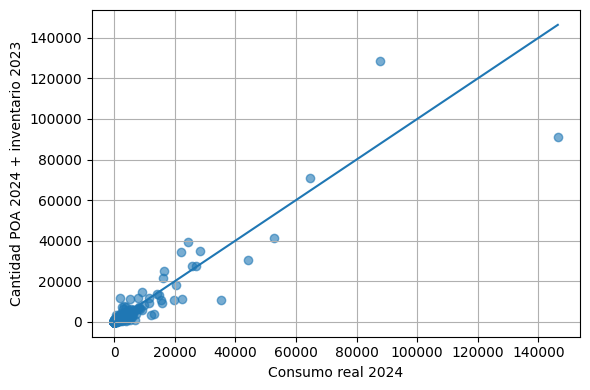

In [ ]:
import matplotlib.pyplot as plt
#3.1. Gráfico 1: Dispersión POA vs real
plt.figure(figsize=(6,4))
plt.scatter(df_base["Consumo_2024"], df_base["q_planpoa24"], alpha=0.6)

maxv = np.nanmax([df_base["Consumo_2024"].max(), df_base["q_planpoa24"].max()])
plt.plot([0, maxv], [0, maxv])  # línea y=x

plt.xlabel("Consumo real 2024")
plt.ylabel("Cantidad POA 2024 + inventario 2023")
#plt.title("Gráfico 1: Dispersión: real vs POA")
plt.grid(True)
plt.tight_layout()
plt.show()

#Puntos cerca de la diagonal ⇒ buena planificacion.
#Puntos sobre la diagonal ⇒ sobreestimación.
#Bajo la diagonal ⇒ subestimación."""

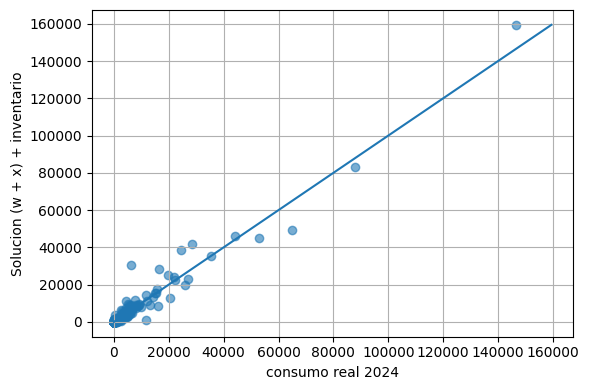

In [ ]:
#3.2. Gráfico 2: Dispersión: Consumo real vs solucion
plt.figure(figsize=(6,4))
plt.scatter(df_base["Consumo_2024"], df_base["q_solucion"], alpha=0.6)

maxv = np.nanmax([df_base["Consumo_2024"].max(), df_base["q_solucion"].max()])
plt.plot([0, maxv], [0, maxv])  # y=x

plt.xlabel("consumo real 2024")
plt.ylabel("Solucion (w + x) + inventario")
#plt.title("Gráfico 2: Dispersión: Consumo real vs solucion")
plt.grid(True)
plt.tight_layout()
plt.show()


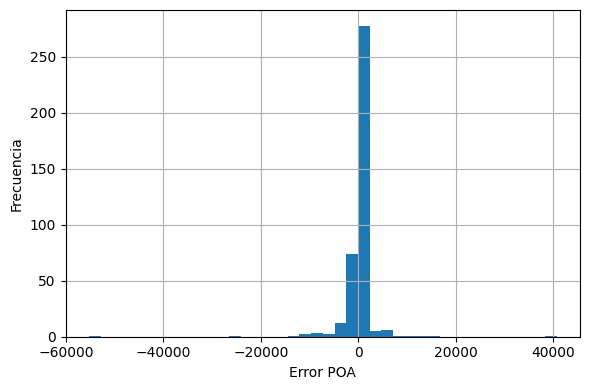

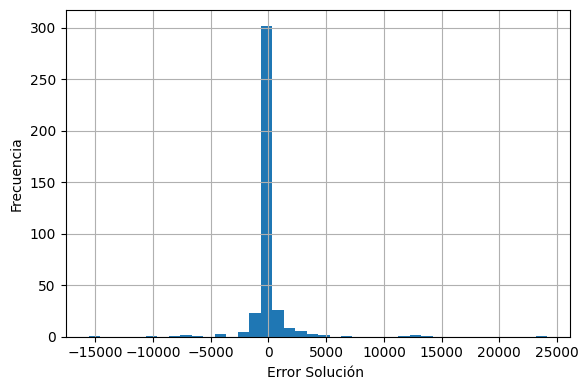

In [ ]:
#3.3. Gráfico 3: Histograma de errores (dos versiones)
# Error  POA vs Consumo real
plt.figure(figsize=(6,4))
plt.hist(df_base["e_POA"].dropna(), bins=40)
plt.xlabel("Error POA")
plt.ylabel("Frecuencia")
#plt.title("Distribución del error de POA vs real")
plt.grid(True)
plt.tight_layout()
plt.show()

# Error Consumo real vs solucion
plt.figure(figsize=(6,4))
plt.hist(df_base["e_w"].dropna(), bins=40)
plt.xlabel("Error Solución ")
plt.ylabel("Frecuencia")
#plt.title("Distribución del error Solucion vs real")
plt.grid(True)
plt.tight_layout()
plt.show()

#Interpretación en texto:
#Si el histograma está centrado cerca de 0 ⇒ poco sesgo.
#Desplazado a la derecha ⇒ sobrecompra/sobreestimación.
#A la izquierda ⇒ subcompra/subestimación.
#Dispersión alta ⇒ inestabilidad del modelo en algunos medicamentos.

In [ ]:
df_base["sobrecompra"] = df_base["e_w"].clip(lower=0)          # excedente
df_base["faltante"]   = (-df_base["e_w"]).clip(lower=0)        # shortage = max(r_real - plan, 0)

top10_sobre = (
    df_base.loc[df_base["sobrecompra"] > 0,
                ["Código", "Consumo_2024","d_demanda_proj", "w_planificadas", "x_extras", "q_solucion", "e_w", "sobrecompra", "ape_w_%"]]
    .sort_values("sobrecompra", ascending=False)
    .head(10)
)

top10_falt = (
    df_base.loc[df_base["faltante"] > 0,
                ["Código", "Consumo_2024","d_demanda_proj", "w_planificadas", "x_extras", "q_solucion", "e_w", "faltante", "ape_w_%"]]
    .sort_values("faltante", ascending=False)
    .head(10)
)
print("\n===== TOP 10 SOBRECOMPRA (excedente) =====")
print(top10_sobre.to_string(index=False))

print("\n===== TOP 10 SUBCOMPRA (faltante) =====")
print(top10_falt.to_string(index=False))



===== TOP 10 SOBRECOMPRA (excedente) =====
 Código  Consumo_2024  d_demanda_proj  w_planificadas  x_extras  q_solucion   e_w  sobrecompra    ape_w_%
C-10-03          6314           30485           29365       975       30485 24171        24171 382.815965
A-12-02         24360           38374           25531      6533       38374 14014        14014  57.528736
N-03-20         28468           41650           31997      3431       41650 13182        13182  46.304623
C-09-02        146382          159431          127036     18278      159431 13049        13049   8.914347
C-07-05         16555           28412           20839      4692       28412 11857        11857  71.621867
B-01-07          4479           11293            9416      1133       11293  6814         6814 152.132172
C-08-07         19626           24904           16312      5663       24904  5278         5278  26.892897
C-09-01          5260            9612            5710      1606        9612  4352         4352  82.737643
C-

## Vallidacion MONETARIA

In [ ]:
#Validacion monetaria
#vamos a analizar y validar con la planificacion que hicieron para el 2024(POA)
df_base2 = df_base[["Código",	"Desripción",	"w_planificadas",	"x_extras",	"r_requerimiento",	"d_demanda_proj",	"Consumo_2024",	"Inventario_2023",	"CantidadPoa",	"q_solucion"]].copy()

# PRA y PRE
df_base2["PRA"] = np.asarray(PRA, dtype=float)
df_base2["PRE"] = np.asarray(PRE, dtype=float)
#unimos las nuevas columnas a la base de datos maestra
df_base2.head(6)

,Código,Desripción,w_planificadas,x_extras,r_requerimiento,d_demanda_proj,Consumo_2024,Inventario_2023,CantidadPoa,q_solucion,PRA,PRE
0,A-02-01,HIDROXIDO DE ALUMINIO Y MAGNESIO,705,201,906,985,928,79,374.0,985,12.570000,14.46
1,A-02-02,OMEPRAZOL,34425,4096,38521,44899,52824,6378,35200.0,44899,0.570000,0.66
2,A-02-03,RANITIDINA,0,0,0,832,2246,960,3300.0,960,0.400000,0.46
3,A-02-04,RANITIDINA,0,0,0,265,267,129,660.0,129,1.820000,2.09
4,A-02-05,OMEPRAZOL,1729,316,2045,3042,3244,997,2860.0,3042,14.006009,16.11
5,A-03-01,ATROPINA SULFATO,0,0,0,49,70,16,20.0,16,3.630000,4.17


In [ ]:
#Cuanto costó todo el consumo real del 2024?
#todo lo extra
faltante_ext = (df_base2["Consumo_2024"] - df_base2["CantidadPoa"] - df_base2["Inventario_2023"]).clip(lower=0)

CostoTotal2024 = (df_base2["CantidadPoa"] * df_base2["PRA"]) + (faltante_ext * df_base2["PRE"])
CostoTotal2024 = CostoTotal2024.sum()

print(f"{CostoTotal2024:,.2f}")


4,645,060.92


In [ ]:
#Costo total planificado
CostoTotalPlan = (df_base2["w_planificadas"] * df_base2["PRA"]) + (df_base2["x_extras"] * df_base2["PRE"])
CostoTotalPlan = CostoTotalPlan.sum()

print(f"{CostoTotalPlan:,.2f}")

4,370,321.18


In [ ]:
# Diferencia absoluta (ahorro si es positivo)
diff_abs = CostoTotal2024 - CostoTotalPlan

# Porcentaje respecto al escenario base
diff_pct = 100 * diff_abs / (CostoTotal2024 + 1e-9)

print(f"Diferencia absoluta (CTpoa - CTplan): {diff_abs:,.2f}")
print(f"Diferencia porcentual sobre CTpoa: {diff_pct:.2f}%")


Diferencia absoluta (CTpoa - CTplan): 274,739.74
Diferencia porcentual sobre CTpoa: 5.91%


In [ ]:

# Costos "presupuestarios" (solo PRA)
CT_PRA_POA  = (df_base2["CantidadPoa"] * df_base2["PRA"]).sum()
CT_PRA_PLAN = (df_base2["w_planificadas"] * df_base2["PRA"]).sum()

# Diferencias y porcentajes vs TP
dif_POA  = TP - CT_PRA_POA
dif_PLAN = TP - CT_PRA_PLAN

pct_POA  = 100 * CT_PRA_POA  / (TP + 1e-9)
pct_PLAN = 100 * CT_PRA_PLAN / (TP + 1e-9)

print(f"TP: {TP:,.2f}")
print(f"CT_PRA_POA (CantidadPoa@PRA): {CT_PRA_POA:,.2f} | {pct_POA:.2f}% del TP | margen (TP-CT): {dif_POA:,.2f}")
print(f"CT_PRA_PLAN (w@PRA):         {CT_PRA_PLAN:,.2f} | {pct_PLAN:.2f}% del TP | margen (TP-CT): {dif_PLAN:,.2f}")

# Flags simples
print("¿POA cumple TP?:", CT_PRA_POA <= TP)
print("¿Plan cumple TP?:", CT_PRA_PLAN <= TP)


TP: 3,628,267.26
CT_PRA_POA (CantidadPoa@PRA): 3,628,267.26 | 100.00% del TP | margen (TP-CT): 0.00
CT_PRA_PLAN (w@PRA):         3,628,266.40 | 100.00% del TP | margen (TP-CT): 0.86
¿POA cumple TP?: True
¿Plan cumple TP?: True


In [ ]:
#VERIFICACION DE VECTORES
# Convertir ambos a arrays numéricos
#pra_np = np.asarray(w_best, dtype=float)
pra_np = pd.to_numeric(datosPrecios['Código'], errors="coerce").to_numpy()
pra_df = pd.to_numeric(datosPoa['Codigo'], errors="coerce").to_numpy()
pra_df = np.round(pra_df,2)

# Comparación

# 1) Verificar misma longitud
print("Len PRA:", len(pra_np), " | Len df_base2['PRA']:", len(pra_df))

# 2) Comparación exacta (ojo: falla si hay floats con pequeñas diferencias)
iguales_exacto = np.array_equal(pra_np, pra_df)
print("¿Iguales exacto?:", iguales_exacto)

# 3) Comparación con tolerancia (recomendado para floats) + tolerancia a NaN
iguales_tol = np.allclose(pra_np, pra_df, rtol=1e-9, atol=1e-9, equal_nan=True)
print("¿Iguales con tolerancia?:", iguales_tol)

# 4) Si NO son iguales, mostrar dónde difieren
if not iguales_tol:
    dif = np.where(~np.isclose(pra_np, pra_df, rtol=1e-9, atol=1e-9, equal_nan=True))[0]
    print("N° diferencias:", len(dif))
    print("Primeras 20 diferencias (índice, PRA, df_PRA):")
    for i in dif[:20]:
        print(i, pra_np[i], pra_df[i])


Len PRA: 390  | Len df_base2['PRA']: 390
¿Iguales exacto?: False
¿Iguales con tolerancia?: True
